<a href="https://colab.research.google.com/github/NinhHTK/ML-CPV-Documents/blob/main/DU_DOAN_TRANG_THAI_LOI_SP_HOI_QUY_DA_BIEN_SE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mục tiêu bài lab:

- Xây dựng và tối ưu mô hình Hồi quy Logistic đa biến (Multivariate Logistic Regression).

- Đánh giá hiệu năng mô hình qua Confusion Matrix, Accuracy, ROC-AUC.

In [202]:
# pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn statsmodels

In [203]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import RandomOverSampler
from statsmodels.stats.outliers_influence import variance_inflation_factor


# BƯỚC 1 EDA

In [204]:
data_path = "manufacturing_defect_dataset.csv"
df = pd.read_csv(data_path)

In [205]:
# 2. Xem cấu trúc dữ liệu
print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3240 entries, 0 to 3239
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductionVolume      3240 non-null   int64  
 1   ProductionCost        3240 non-null   float64
 2   SupplierQuality       3240 non-null   float64
 3   DeliveryDelay         3240 non-null   int64  
 4   DefectRate            3240 non-null   float64
 5   QualityScore          3240 non-null   float64
 6   MaintenanceHours      3240 non-null   int64  
 7   DowntimePercentage    3240 non-null   float64
 8   InventoryTurnover     3240 non-null   float64
 9   StockoutRate          3240 non-null   float64
 10  WorkerProductivity    3240 non-null   float64
 11  SafetyIncidents       3240 non-null   int64  
 12  EnergyConsumption     3240 non-null   float64
 13  EnergyEfficiency      3240 non-null   float64
 14  AdditiveProcessTime   3240 non-null   float64
 15  AdditiveMaterialCost 

In [206]:
# 3. Kiểm tra giá trị NA
print(df.isnull().sum())

ProductionVolume        0
ProductionCost          0
SupplierQuality         0
DeliveryDelay           0
DefectRate              0
QualityScore            0
MaintenanceHours        0
DowntimePercentage      0
InventoryTurnover       0
StockoutRate            0
WorkerProductivity      0
SafetyIncidents         0
EnergyConsumption       0
EnergyEfficiency        0
AdditiveProcessTime     0
AdditiveMaterialCost    0
DefectStatus            0
dtype: int64


In [207]:
# 4. Biến mục tiêu trong Pandas thường tự hiểu là category khi ta chạy model,
# nhưng có thể ép kiểu
df['DefectStatus'] = df['DefectStatus'].astype(int)

In [208]:
# 5. Kiểm tra tỷ lệ mất cân bằng
print("Số lượng các lớp:")
print(df['DefectStatus'].value_counts())
print("Tỷ lệ các lớp:")
print(df['DefectStatus'].value_counts(normalize=True))

Số lượng các lớp:
DefectStatus
1    2723
0     517
Name: count, dtype: int64
Tỷ lệ các lớp:
DefectStatus
1    0.840432
0    0.159568
Name: proportion, dtype: float64


# BƯỚC 2: CHIA TẬP DỮ LIỆU VÀ XỬ LÝ MẤT CÂN BẰNG

In [209]:
# Tách biến độc lập (X) và biến mục tiêu (y)
X = df.drop('DefectStatus', axis=1)
y = df['DefectStatus']

In [210]:
# Chia dữ liệu: 80% Train / 20% Test (stratify giúp giữ nguyên tỷ lệ nhãn)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

print("Tỷ lệ trước khi cân bằng (Train):")
print(y_train.value_counts())

Tỷ lệ trước khi cân bằng (Train):
DefectStatus
1    2178
0     414
Name: count, dtype: int64


Theo mô tả dữ liệu, tỷ lệ hàng lỗi (1) ít xuất hiện hơn hàng bình thường (0). Nếu giữ nguyên, mô hình sẽ bị thiên vị (bias) về nhóm đa số. Ta sẽ chia tập dữ liệu trước, sau đó áp dụng kỹ thuật ROSE (Random Over-Sampling Examples) trên tập Train để cân bằng.

In [211]:
# Áp dụng SMOTE (thay vì RandomOverSampler như trong ví dụ gốc)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=2026)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("\nTỷ lệ sau khi cân bằng (với SMOTE):")
print(y_train_bal.value_counts())


Tỷ lệ sau khi cân bằng (với SMOTE):
DefectStatus
1    2178
0    2178
Name: count, dtype: int64


**Các bạn cân bằng Phương Pháp SMOT**

# BƯỚC 3: HUẤN LUYỆN MÔ HÌNH HỒI QUY LOGISTIC ĐA BIẾN

In [212]:
# Thêm hằng số (intercept) vào dữ liệu cho mô hình statsmodels
X_train_bal_sm = sm.add_constant(X_train_bal)

# Xây dựng và huấn luyện mô hình (Logit)
logistic_model = sm.Logit(y_train_bal, X_train_bal_sm).fit()

# Xem bảng tóm tắt (chú ý cột P>|z|)
print(logistic_model.summary())

Optimization terminated successfully.
         Current function value: 0.448801
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           DefectStatus   No. Observations:                 4356
Model:                          Logit   Df Residuals:                     4339
Method:                           MLE   Df Model:                           16
Date:                Wed, 15 Jul 2026   Pseudo R-squ.:                  0.3525
Time:                        10:10:02   Log-Likelihood:                -1955.0
converged:                       True   LL-Null:                       -3019.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -2.5348      1.064     -2.382      0.017      -4.620      -0.449

lưu ý: Khi đọc bảng summary(), các bạn chú ý cột Pr(>|z|). Các biến có dấu sao (P-value < 0.05) là những biến có ý nghĩa thống kê cao, tác động mạnh đến tỷ lệ lỗi của sản phẩm (ví dụ như DefectRate, QualityScore, DowntimePercentage).

# BƯỚC 5: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST

Do đầu ra của Logistic Regression là xác suất (từ 0 đến 1), ta cần chọn một ngưỡng (Threshold = 0.5) để phân loại.

In [213]:
# Thêm hằng số vào tập Test
X_test_sm = sm.add_constant(X_test)

# 1. Dự đoán xác suất
pred_prob = logistic_model.predict(X_test_sm)

# 2. Chuyển đổi xác suất thành nhãn (Ngưỡng 0.5)
pred_class = (pred_prob >= 0.5).astype(int)

# 3. Tạo Ma trận nhầm lẫn
conf_matrix = confusion_matrix(y_test, pred_class)
print("Confusion Matrix:\n", conf_matrix)

# Báo cáo phân loại chi tiết (Accuracy, Precision, Recall, F1)
print("\nClassification Report:\n", classification_report(y_test, pred_class))

Confusion Matrix:
 [[ 72  31]
 [116 429]]

Classification Report:
               precision    recall  f1-score   support

           0       0.38      0.70      0.49       103
           1       0.93      0.79      0.85       545

    accuracy                           0.77       648
   macro avg       0.66      0.74      0.67       648
weighted avg       0.85      0.77      0.80       648



# BƯỚC 6: ĐÁNH GIÁ ROC VÀ CHỈ SỐ AUC

chỉ số AUC (Area Under the Curve) là thước đo chuẩn nhất cho bài toán phân loại nhị phân.

chỉ số AUC (Area Under the Curve) của một mô hình phân loại nhị phân luôn nằm trong khoảng từ $0$ đến $1$. Cụ thể:

$AUC = 0.5$: Mô hình đoán mò ngẫu nhiên (giống như tung đồng xu).

$AUC > 0.7$: Mô hình dùng được.

$AUC > 0.9$: Mô hình cực kỳ tốt.

$AUC < 0.5$: Mô hình đang dự đoán mò.

Chỉ số AUC của mô hình là: 0.8002


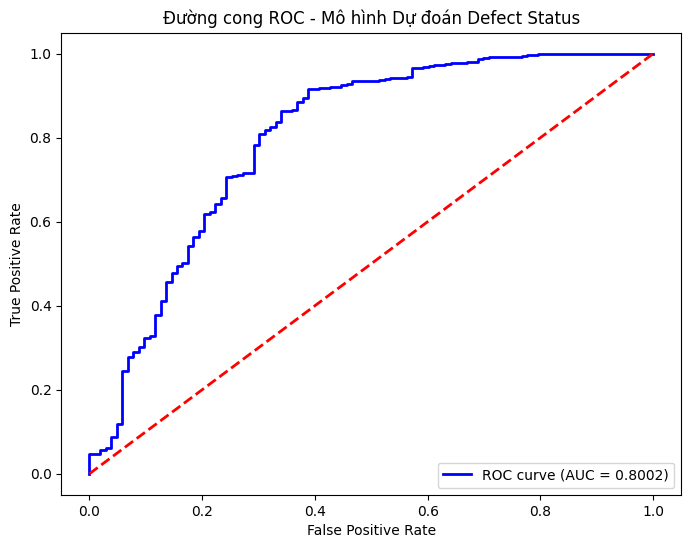

In [214]:
# Tính toán ROC và AUC
fpr, tpr, thresholds = roc_curve(y_test, pred_prob)
auc_value = auc(fpr, tpr)

print(f"Chỉ số AUC của mô hình là: {auc_value:.4f}")

# Vẽ đồ thị ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {auc_value:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--') # Đường chéo cơ sở
plt.title('Đường cong ROC - Mô hình Dự đoán Defect Status')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# BƯỚC 7: XÁC ĐỊNH ĐỘ QUAN TRỌNG CỦA BIẾN (FEATURE IMPORTANCE)

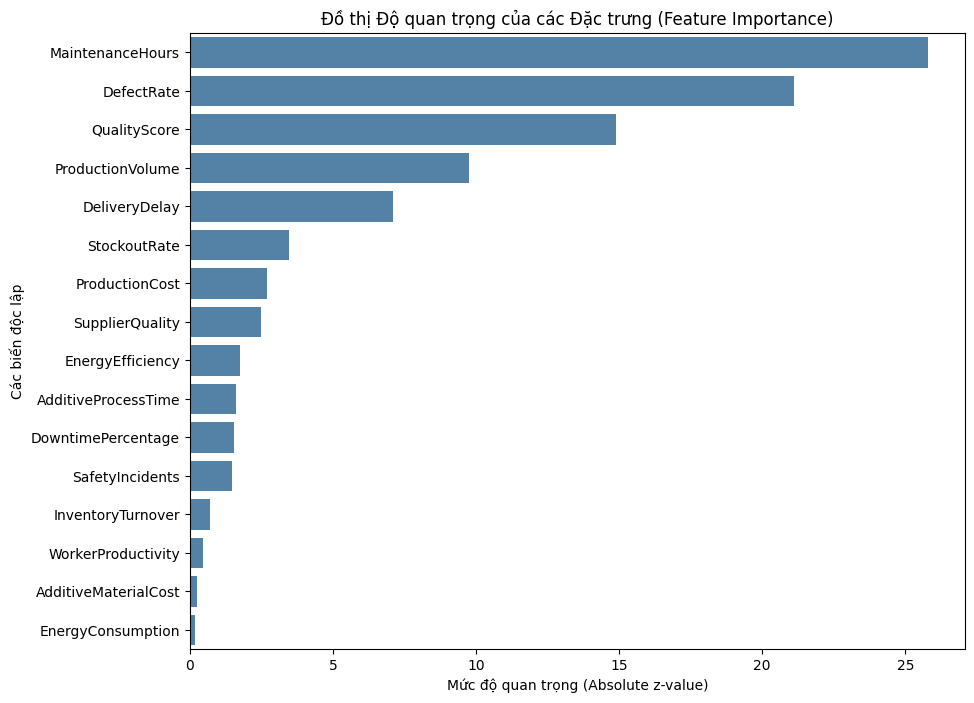

In [215]:
#  Tính độ quan trọng (Absolute z-values) và tạo dataframe
importance_df = pd.DataFrame({
    'Feature': X_train_bal_sm.columns,
    'Importance': np.abs(logistic_model.tvalues) # tvalues trong Logit chính là z-values
})

# Bỏ cột hằng số (const) và sắp xếp
importance_df = importance_df[importance_df['Feature'] != 'const']
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# 3. Trực quan hóa
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, color='steelblue')
plt.title('Đồ thị Độ quan trọng của các Đặc trưng (Feature Importance)')
plt.xlabel('Mức độ quan trọng (Absolute z-value)')
plt.ylabel('Các biến độc lập')
plt.show()

# BƯỚC 8: KIỂM TRA ĐA CỘNG TUYẾN (MULTICOLLINEARITY)

Đa cộng tuyến xảy ra khi các biến độc lập có mối quan hệ tuyến tính mạnh với nhau (ví dụ: ProductionVolume tăng thì ProductionCost thường tăng theo), làm sai lệch hệ số hồi quy. Ta dùng chỉ số VIF (Variance Inflation Factor) để kiểm tra.

Quy tắc: VIF > 5 hoặc 10 là có dấu hiệu đa cộng tuyến nghiêm trọng cần loại bỏ bớt biến.

                 Feature         VIF
0       ProductionVolume    5.703785
1         ProductionCost    9.197531
2        SupplierQuality  166.166836
3          DeliveryDelay    3.219379
4             DefectRate    5.338300
5           QualityScore   58.006290
6       MaintenanceHours    3.233203
7     DowntimePercentage    4.448288
8      InventoryTurnover    8.869806
9           StockoutRate    4.485582
10    WorkerProductivity  165.046519
11       SafetyIncidents    3.776462
12     EnergyConsumption    8.134558
13      EnergyEfficiency    8.840718
14   AdditiveProcessTime    6.028605
15  AdditiveMaterialCost    8.191594


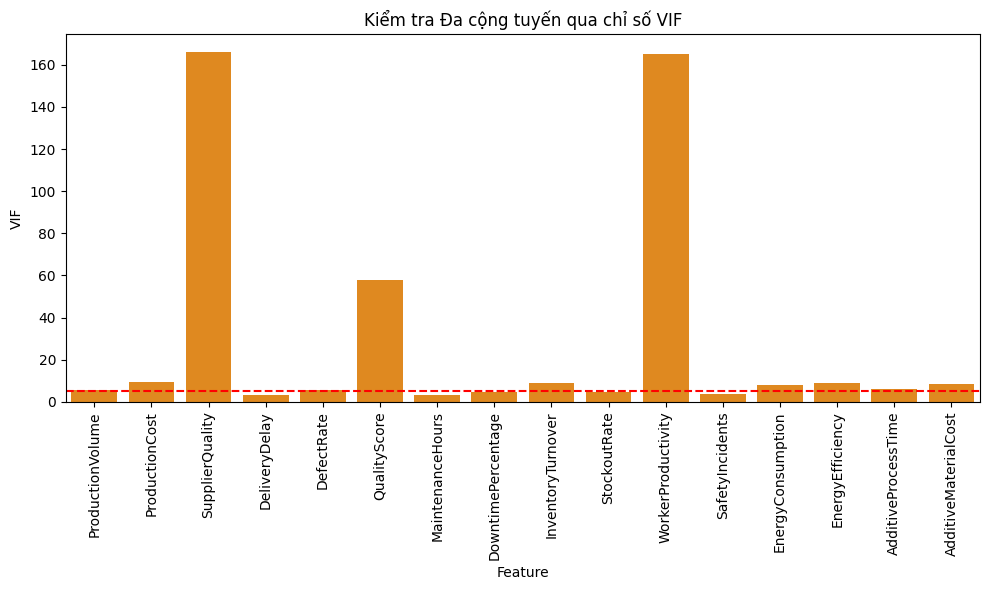

In [216]:
# Tính chỉ số VIF (Không tính VIF cho hằng số const)
vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_bal.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_bal.values, i)
                   for i in range(len(X_train_bal.columns))]

print(vif_data)

# Trực quan hóa chỉ số VIF
plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='VIF', data=vif_data, color='darkorange')
plt.axhline(y=5, color='red', linestyle='--') # Ngưỡng cảnh báo
plt.xticks(rotation=90)
plt.title('Kiểm tra Đa cộng tuyến qua chỉ số VIF')
plt.tight_layout()
plt.show()

# BƯỚC 9: LỌC BIẾN (FEATURE SELECTION) & SO SÁNH MÔ HÌNH

xây dựng một mô hình thu gọn (reduced_model) bằng cách chỉ giữ lại các biến có ý nghĩa thống kê cao ($P\text{-value} < 0.05$) từ bảng summary(), sau đó dùng kiểm định hoặc so sánh đường cong ROC-AUC giữa hai mô hình để xem hiệu năng có bị giảm sút hay không.

In [217]:
# 1. Xây dựng mô hình thu gọn
features_reduced = ['MaintenanceHours', 'DefectRate', 'QualityScore', 'ProductionVolume' ] # These are example features, actual features should be selected based on p-value < 0.05 from the summary.
X_train_reduced_sm = sm.add_constant(X_train_bal[features_reduced])

reduced_model = sm.Logit(y_train_bal, X_train_reduced_sm).fit()

Optimization terminated successfully.
         Current function value: 0.459144
         Iterations 6


In [218]:
# 2. Dự đoán trên tập Test
X_test_reduced_sm = sm.add_constant(X_test[features_reduced])
pred_prob_reduced = reduced_model.predict(X_test_reduced_sm)

In [219]:
# 3. Tính ROC và AUC cho cả 2 mô hình
fpr_red, tpr_red, _ = roc_curve(y_test, pred_prob_reduced)
auc_reduced = auc(fpr_red, tpr_red)

In [220]:
# 4. So sánh AUC
print(f"AUC Full Model    : {auc_value:.4f}")
print(f"AUC Reduced Model : {auc_reduced:.4f}")

AUC Full Model    : 0.8002
AUC Reduced Model : 0.8089


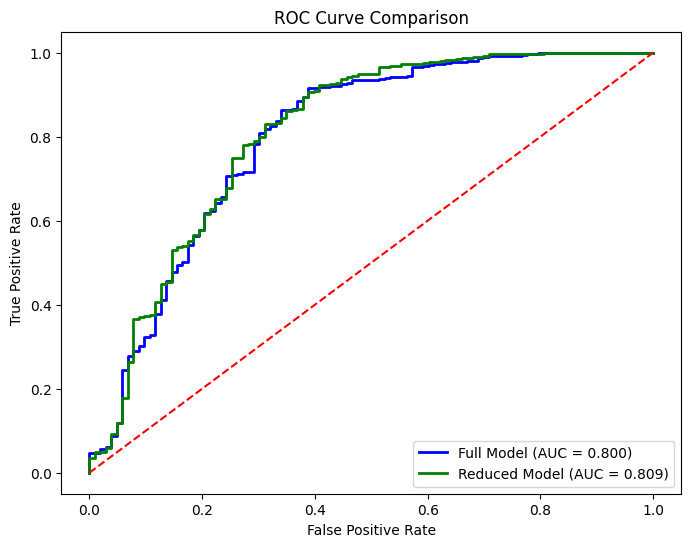

In [221]:
# 5. Vẽ ROC so sánh
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'Full Model (AUC = {auc_value:.3f})')
plt.plot(fpr_red, tpr_red, color='green', lw=2, label=f'Reduced Model (AUC = {auc_reduced:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

# BƯỚC 10: TẠO BỘ DỮ LIỆU MỚI VÀ DỰ ĐOÁN (INFERENCE)

In [222]:
# 1. Tạo dataframe dữ liệu mới
new_data = {
    'ProductionVolume': [500, 150],
    'ProductionCost': [12000, 6500],
    'SupplierQuality': [95.5, 82.1],
    'DeliveryDelay': [1, 4],
    'DefectRate': [1.2, 4.8],
    'QualityScore': [92.0, 61.5],
    'MaintenanceHours': [12, 2],
    'DowntimePercentage': [0.01, 0.04],
    'InventoryTurnover': [5.5, 3.1],
    'StockoutRate': [0.02, 0.08],
    'WorkerProductivity': [94.0, 81.0],
    'SafetyIncidents': [0, 3],
    'EnergyConsumption': [2500, 4200],
    'EnergyEfficiency': [0.4, 0.15],
    'AdditiveProcessTime': [4.5, 8.2],
    'AdditiveMaterialCost': [250, 450]
}
new_production_runs = pd.DataFrame(new_data)

In [223]:
# thứ tự cột giống y hệt như lúc huấn luyện
new_production_runs = new_production_runs[X_train.columns]

In [224]:
# Thêm hằng số const
new_production_runs_sm = sm.add_constant(new_production_runs)

In [225]:
# Dự đoán xác suất
predicted_probabilities = logistic_model.predict(new_production_runs_sm)

In [226]:
# Phân lớp nhãn
predicted_classes = (predicted_probabilities >= 0.5).astype(int)
predicted_classes = predicted_classes.map({0: 'Low Defect (0)', 1: 'High Defect (1)'})

In [227]:
# Gộp kết quả
inference_results = pd.DataFrame({
    'Run_ID': ["Lô hàng A", "Lô hàng B"],
    'Probability_Of_Defect': predicted_probabilities,
    'Predicted_Status': predicted_classes
})

print(" KẾT QUẢ DỰ ĐOÁN CHO DỮ LIỆU MỚI")
print(inference_results)

 KẾT QUẢ DỰ ĐOÁN CHO DỮ LIỆU MỚI
      Run_ID  Probability_Of_Defect Predicted_Status
0  Lô hàng A               0.176924   Low Defect (0)
1  Lô hàng B               0.812792  High Defect (1)


Có 3 nhóm phương pháp chính (tác động lên dữ liệu) và 1 phương pháp ở mức thuật toán (tác động lên mô hình). Tổng cộng thường dùng khoảng 6 kỹ thuật phổ biến nhất.

Thư viện imbalanced-learn và scikit-learn

tách biến độc lập X, biến mục tiêu y và chia theo tỷ lệ 80/20.

In [228]:
# 1. Đọc dữ liệu
data_path = "manufacturing_defect_dataset.csv"
df = pd.read_csv(data_path)
df['DefectStatus'] = df['DefectStatus'].astype(int)

# Tách X, y
X = df.drop('DefectStatus', axis=1)
y = df['DefectStatus']

In [229]:
# 2. Chia dữ liệu thành Train (80%) và Test (20%)
# Tham số stratify=y để giữ nguyên tỷ lệ 84/16 ở cả 2 tập Train và Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2026, stratify=y
)

print("Kích thước tập Train gốc:")
print(y_train.value_counts())

Kích thước tập Train gốc:
DefectStatus
1    2178
0     414
Name: count, dtype: int64


# Nhóm 1: Oversampling (Tăng lấy mẫu nhóm thiểu số)

## ROS - Over-Sampling (Sao chép ngẫu nhiên lớp lỗi)

Sao chép ngẫu nhiên các mẫu của nhóm thiểu số. Nhược điểm là dễ gây ra hiện tượng overfitting.

In [230]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

ros = RandomOverSampler(random_state=2026)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print("Tỷ lệ tập Train sau Random Over-Sampling:")
print(Counter(y_train_ros))

Tỷ lệ tập Train sau Random Over-Sampling:
Counter({1: 2178, 0: 2178})


# PHƯƠNG PHÁP SMOTE (Tự tạo thêm dữ liệu lỗi mới)

Thay vì sao chép, SMOTE nội suy và sinh ra các điểm dữ liệu mới nằm giữa các điểm dữ liệu cũ của nhóm thiểu số. Đây là phương pháp hay dùng

In [231]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=2026)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Tỷ lệ tập Train sau SMOTE:")
print(Counter(y_train_smote))

Tỷ lệ tập Train sau SMOTE:
Counter({1: 2178, 0: 2178})


# NHÓM 2: UNDERSAMPLING (GIẢM MẪU ĐA SỐ)

Nhóm này xóa bớt dữ liệu của lớp nhiều (lớp 0) cho bằng với lớp ít (lớp 1). Phù hợp khi có một tập dữ liệu lớn.


## Random Under-Sampling (Xóa bớt dữ liệu bình thường)

Xóa ngẫu nhiên các mẫu của nhóm đa số. Nhược điểm là có thể làm mất đi các thông tin quan trọng của tập dữ liệu.

In [232]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=2026)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)

print("Tỷ lệ tập Train sau Random Under-Sampling:")
print(Counter(y_train_rus))

Tỷ lệ tập Train sau Random Under-Sampling:
Counter({0: 414, 1: 414})


Tomek Links (Dọn dẹp ranh giới quyết định)

Không xóa ngẫu nhiên mà tìm các cặp điểm dữ liệu (1 điểm lớp 0, 1 điểm lớp 1) nằm sát nhau nhất (gọi là Tomek Link). Sau đó, thuật toán sẽ xóa điểm thuộc lớp đa số đi để làm rõ ràng đường ranh giới phân loại. Phương pháp này thường không làm cân bằng tỷ lệ 50-50 mà chỉ loại bỏ ranh giới.

In [233]:
from imblearn.under_sampling import TomekLinks

tomek = TomekLinks()
X_train_tomek, y_train_tomek = tomek.fit_resample(X_train, y_train)

print("Tỷ lệ tập Train sau Tomek Links:")
print(Counter(y_train_tomek))

Tỷ lệ tập Train sau Tomek Links:
Counter({1: 1994, 0: 414})


# NHÓM 3: HYBRID (KẾT HỢP SONG SONG)
Kết hợp cả tăng và giảm mẫu để lấy ưu điểm của cả hai.

## SMOTETomek (Sinh mẫu mới + Dọn dẹp ranh giới)

 Đầu tiên dùng SMOTE để sinh thêm dữ liệu nhóm thiểu số, sau đó dùng Tomek Links để xóa bớt các điểm bị nhiễu hoặc nằm quá sát nhau ở ranh giới.

In [234]:
from imblearn.combine import SMOTETomek

smote_tomek = SMOTETomek(random_state=2026)
X_train_smt, y_train_smt = smote_tomek.fit_resample(X_train, y_train)

print("Tỷ lệ tập Train sau SMOTETomek:")
print(Counter(y_train_smt))

Tỷ lệ tập Train sau SMOTETomek:
Counter({1: 2093, 0: 2093})


# NHÓM 4: TRỌNG SỐ THUẬT TOÁN (COST-SENSITIVE)

Phương pháp này không thay đổi dữ liệu gốc, mà thay đổi cách mô hình tính toán sự trừng phạt (loss/cost) khi đoán sai.

## Class Weights (Phạt nặng khi đoán sai lỗi)

Phương pháp này Bắt mô hình phải chú ý hơn vào lớp thiểu số. Nếu đoán sai lớp thiểu số, lỗi sẽ bị phạt nặng gấp nhiều lần so với đoán sai lớp đa số. Hầu hết các mô hình trong scikit-learn đều hỗ trợ tham số này.

In [235]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Khởi tạo bộ chuẩn hóa dữ liệu
scaler = StandardScaler()

# 2. Học thang đo từ tập Train và biến đổi (Scale) dữ liệu tập Train
# Bước này giúp đưa tất cả các biến về cùng một hệ quy chiếu
X_train_scaled = scaler.fit_transform(X_train)

# Lưu ý: Khi các bạn muốn đánh giá tập Test thì cũng cần scale tập Test:
# X_test_scaled = scaler.transform(X_test)

In [236]:
# 3. Khởi tạo mô hình với max_iter=1000 (tăng số vòng lặp) và class_weight='balanced'
logistic_model_weighted = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=2026
)

# 4. Huấn luyện trên dữ liệu đã được chuẩn hóa
logistic_model_weighted.fit(X_train_scaled, y_train)

print("Mô hình Logistic Regression đã được huấn luyện OK")

Mô hình Logistic Regression đã được huấn luyện OK


In [237]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# scale cả tập Test bằng StandardScaler đã học từ tập Train trước khi dự đoán
X_test_scaled = scaler.transform(X_test)


## IN THÔNG TIN HỆ SỐ HỒI QUY (COEFFICIENTS)

In [238]:
print("THÔNG TIN HỆ SỐ MÔ HÌNH (COEFFICIENTS) ")
print(f"Hệ số chặn (Intercept / Bias): {logistic_model_weighted.intercept_[0]:.4f}\n")

# Ghép tên các biến với hệ số tương ứng
coef_df = pd.DataFrame({
    'Biến độc lập (Feature)': X_train.columns,
    'Hệ số hồi quy (Coefficient)': logistic_model_weighted.coef_[0]
})

# Sắp xếp theo thứ tự ảnh hưởng từ lớn đến nhỏ
# Hệ số dương lớn: Làm tăng khả năng bị lỗi (DefectStatus = 1)
# Hệ số âm lớn: Làm giảm khả năng bị lỗi
coef_df = coef_df.sort_values(by='Hệ số hồi quy (Coefficient)', ascending=False)
print("Mức độ ảnh hưởng của các biến độc lập lên tỷ lệ lỗi:")
print(coef_df.to_string(index=False))


THÔNG TIN HỆ SỐ MÔ HÌNH (COEFFICIENTS) 
Hệ số chặn (Intercept / Bias): 0.7241

Mức độ ảnh hưởng của các biến độc lập lên tỷ lệ lỗi:
Biến độc lập (Feature)  Hệ số hồi quy (Coefficient)
      MaintenanceHours                     1.041077
            DefectRate                     0.866090
      ProductionVolume                     0.348597
          StockoutRate                     0.146188
       SupplierQuality                     0.107311
        ProductionCost                     0.099725
         DeliveryDelay                     0.087663
   AdditiveProcessTime                     0.062290
    DowntimePercentage                     0.060939
     EnergyConsumption                     0.000554
    WorkerProductivity                    -0.003713
     InventoryTurnover                    -0.005872
  AdditiveMaterialCost                    -0.011835
      EnergyEfficiency                    -0.067897
       SafetyIncidents                    -0.096115
          QualityScore              

## ĐÁNH GIÁ TRÊN TẬP HUẤN LUYỆN (TRAIN SET)

In [239]:
y_train_pred = logistic_model_weighted.predict(X_train_scaled)
y_train_pred_proba = logistic_model_weighted.predict_proba(X_train_scaled)[:, 1]


print("ĐÁNH GIÁ TRÊN TẬP HUẤN LUYỆN (TRAIN SET) ")

print(f"Độ chính xác (Accuracy): {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Chỉ số ROC-AUC         : {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_train, y_train_pred))
print("\nBáo cáo phân loại chi tiết (Classification Report):")
print(classification_report(y_train, y_train_pred, target_names=['Bình thường (0)', 'Lỗi (1)']))

ĐÁNH GIÁ TRÊN TẬP HUẤN LUYỆN (TRAIN SET) 
Độ chính xác (Accuracy): 0.7735
Chỉ số ROC-AUC         : 0.8499

Ma trận nhầm lẫn (Confusion Matrix):
[[ 336   78]
 [ 509 1669]]

Báo cáo phân loại chi tiết (Classification Report):
                 precision    recall  f1-score   support

Bình thường (0)       0.40      0.81      0.53       414
        Lỗi (1)       0.96      0.77      0.85      2178

       accuracy                           0.77      2592
      macro avg       0.68      0.79      0.69      2592
   weighted avg       0.87      0.77      0.80      2592



##  ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ (TEST SET)

In [240]:
y_test_pred = logistic_model_weighted.predict(X_test_scaled)
y_test_pred_proba = logistic_model_weighted.predict_proba(X_test_scaled)[:, 1]


print(" ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ (TEST SET) ")

print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Chỉ số ROC-AUC         : {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print("\nMa trận nhầm lẫn (Confusion Matrix):")
print(confusion_matrix(y_test, y_test_pred))
print("\nReport phân loại (Classification Report):")
print(classification_report(y_test, y_test_pred, target_names=['Bình thường (0)', 'Lỗi (1)']))

 ĐÁNH GIÁ TRÊN TẬP KIỂM THỬ (TEST SET) 
Độ chính xác (Accuracy): 0.7562
Chỉ số ROC-AUC         : 0.8032

Ma trận nhầm lẫn (Confusion Matrix):
[[ 71  32]
 [126 419]]

Report phân loại (Classification Report):
                 precision    recall  f1-score   support

Bình thường (0)       0.36      0.69      0.47       103
        Lỗi (1)       0.93      0.77      0.84       545

       accuracy                           0.76       648
      macro avg       0.64      0.73      0.66       648
   weighted avg       0.84      0.76      0.78       648

